In [1]:
!pip install transformers torch datasets scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All imports done")
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

✅ All imports done
GPU available: True
Device: NVIDIA A100-SXM4-40GB


In [3]:
# CELL 3 — Load HC3
print("Loading HC3...")
import requests, json

rows = []
url = "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"
response = requests.get(url)
lines = response.text.strip().split("\n")

for line in lines:
    row = json.loads(line)
    source = row.get("source", "general")
    for ans in row.get("human_answers", []):
        if ans and len(ans.strip()) > 50:
            rows.append({"text": ans.strip(), "label": 0, "domain": source})
    for ans in row.get("chatgpt_answers", []):
        if ans and len(ans.strip()) > 50:
            rows.append({"text": ans.strip(), "label": 1, "domain": source})

hc3 = pd.DataFrame(rows)
print(f"✅ HC3 loaded: {hc3.shape}")
print(hc3["label"].value_counts())
print(hc3["domain"].value_counts())
print("\nSample human:")
print(hc3[hc3["label"]==0]["text"].iloc[0][:200])
print("\nSample AI:")
print(hc3[hc3["label"]==1]["text"].iloc[0][:200])

Loading HC3...
✅ HC3 loaded: (84392, 3)
label
0    57553
1    26839
Name: count, dtype: int64
domain
reddit_eli5    67040
finance         8416
open_qa         4673
medicine        2579
wiki_csai       1684
Name: count, dtype: int64

Sample human:
Basically there are many categories of " Best Seller " . Replace " Best Seller " by something like " Oscars " and every " best seller " book is basically an " oscar - winning " book . May not have won

Sample AI:
There are many different best seller lists that are published by various organizations, and the New York Times is just one of them. The New York Times best seller list is a weekly list that ranks the 


In [4]:
# CELL 4 — Load NYT
print("Loading NYT...")
ds_nyt = load_dataset("gsingh1-py/train", split="train")
nyt_raw = ds_nyt.to_pandas()

nyt_rows = []
ai_cols = ['gemma-2-9b', 'mistral-7B', 'qwen-2-72B', 'llama-8B',
           'accounts/yi-01-ai/models/yi-large', 'GPT_4-o']

for _, row in nyt_raw.iterrows():
    if pd.notna(row['Human_story']) and len(str(row['Human_story']).strip()) > 50:
        nyt_rows.append({"text": str(row['Human_story']).strip(), "label": 0, "domain": "news"})
    for col in ai_cols:
        if pd.notna(row[col]) and len(str(row[col]).strip()) > 50:
            nyt_rows.append({"text": str(row[col]).strip(), "label": 1, "domain": "news"})

nyt_df = pd.DataFrame(nyt_rows)
print(f"✅ NYT: {nyt_df.shape}")
print(nyt_df["label"].value_counts())

Loading NYT...


Repo card metadata block was not found. Setting CardData to empty.


train.csv:   0%|          | 0.00/161M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7321 [00:00<?, ? examples/s]

✅ NYT: (51168, 3)
label
1    43882
0     7286
Name: count, dtype: int64


In [5]:
# CELL 5 — Load RAID full
print("Loading RAID...")
ds_raid = load_dataset("liamdugan/raid")
print(f"Splits: {ds_raid.keys()}")

raid_raw = ds_raid["train"].to_pandas()
print(f"Shape: {raid_raw.shape}")
print(f"Domains:\n{raid_raw['domain'].value_counts()}")
print(f"Models:\n{raid_raw['model'].value_counts()}")

raid_raw["text"] = raid_raw["generation"]
raid_raw["label"] = raid_raw["model"].apply(lambda x: 0 if x == "human" else 1)
print(f"\nLabel counts:\n{raid_raw['label'].value_counts()}")

Loading RAID...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.8G [00:00<?, ?B/s]

extra.csv:   0%|          | 0.00/3.71G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating extra split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

Splits: dict_keys(['train', 'extra'])
Shape: (5615820, 11)
Domains:
domain
books        748020
news         747600
wiki         747180
reddit       747180
recipes      744240
poetry       743820
abstracts    741720
reviews      396060
Name: count, dtype: int64
Models:
model
llama-chat      641808
mpt             641808
mpt-chat        641808
gpt2            641808
mistral-chat    641808
mistral         641808
cohere          320904
gpt3            320904
gpt4            320904
chatgpt         320904
cohere-chat     320904
human           160452
Name: count, dtype: int64

Label counts:
label
1    5455368
0     160452
Name: count, dtype: int64


In [6]:
# CELL 6 — Balance and sample all 3 datasets
print("Balancing all datasets...")

# ── HC3 ──────────────────────────────────────────
hc3_h = hc3[hc3["label"]==0].sample(5000, random_state=42)
hc3_a = hc3[hc3["label"]==1].sample(5000, random_state=42)
hc3_bal = pd.concat([hc3_h, hc3_a]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ HC3 balanced: {hc3_bal.shape}")
print(hc3_bal["label"].value_counts())

# ── NYT ──────────────────────────────────────────
nyt_h = nyt_df[nyt_df["label"]==0].sample(5000, random_state=42)
nyt_a = nyt_df[nyt_df["label"]==1].sample(5000, random_state=42)
nyt_bal = pd.concat([nyt_h, nyt_a]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"✅ NYT balanced: {nyt_bal.shape}")
print(nyt_bal["label"].value_counts())

# ── RAID ─────────────────────────────────────────
# Sample evenly across all 8 domains
raid_rows = []
for domain in raid_raw["domain"].unique():
    d = raid_raw[raid_raw["domain"]==domain]
    h = d[d["label"]==0].sample(min(625, len(d[d["label"]==0])), random_state=42)
    a = d[d["label"]==1].sample(min(625, len(d[d["label"]==1])), random_state=42)
    raid_rows.append(pd.concat([h, a]))

raid_bal = pd.concat(raid_rows).sample(frac=1, random_state=42).reset_index(drop=True)
raid_bal = raid_bal[["text","label","domain"]]
print(f"✅ RAID balanced: {raid_bal.shape}")
print(raid_bal["label"].value_counts())
print(raid_bal["domain"].value_counts())

Balancing all datasets...
✅ HC3 balanced: (10000, 3)
label
1    5000
0    5000
Name: count, dtype: int64
✅ NYT balanced: (10000, 3)
label
1    5000
0    5000
Name: count, dtype: int64
✅ RAID balanced: (10000, 3)
label
0    5000
1    5000
Name: count, dtype: int64
domain
reddit       1250
poetry       1250
books        1250
abstracts    1250
recipes      1250
news         1250
wiki         1250
reviews      1250
Name: count, dtype: int64


In [7]:
# CELL 7 — Train/Test splits for all 3 datasets
print("Creating train/test splits...")

# HC3
X_tr_hc3, X_te_hc3, y_tr_hc3, y_te_hc3 = train_test_split(
    hc3_bal["text"], hc3_bal["label"],
    test_size=0.2, random_state=42, stratify=hc3_bal["label"]
)

# NYT
X_tr_nyt, X_te_nyt, y_tr_nyt, y_te_nyt = train_test_split(
    nyt_bal["text"], nyt_bal["label"],
    test_size=0.2, random_state=42, stratify=nyt_bal["label"]
)

# RAID
X_tr_raid, X_te_raid, y_tr_raid, y_te_raid = train_test_split(
    raid_bal["text"], raid_bal["label"],
    test_size=0.2, random_state=42, stratify=raid_bal["label"]
)

print(f"✅ HC3  — Train: {len(X_tr_hc3)}  Test: {len(X_te_hc3)}")
print(f"✅ NYT  — Train: {len(X_tr_nyt)}  Test: {len(X_te_nyt)}")
print(f"✅ RAID — Train: {len(X_tr_raid)}  Test: {len(X_te_raid)}")

Creating train/test splits...
✅ HC3  — Train: 8000  Test: 2000
✅ NYT  — Train: 8000  Test: 2000
✅ RAID — Train: 8000  Test: 2000


In [8]:
# CELL 8 — Classical Models (NB, LR, SVM) on all 3 datasets
def run_classical(X_train, X_test, y_train, y_test, dataset_name):
    print(f"\n{'='*50}")
    print(f"CLASSICAL MODELS — {dataset_name}")
    print(f"{'='*50}")
    results = {}

    # CountVec for NB
    cvec = CountVectorizer(stop_words="english", max_features=5000)
    Xtr_c = cvec.fit_transform(X_train)
    Xte_c = cvec.transform(X_test)

    # TF-IDF for LR + SVM
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    Xtr_t = tfidf.fit_transform(X_train)
    Xte_t = tfidf.transform(X_test)

    # Naive Bayes
    nb = MultinomialNB()
    nb.fit(Xtr_c, y_train)
    nb_pred = nb.predict(Xte_c)
    nb_acc = accuracy_score(y_test, nb_pred)
    print(f"\nNaive Bayes:          {nb_acc:.4f}")
    print(classification_report(y_test, nb_pred, target_names=["Human","AI"]))
    results["Naive Bayes"] = nb_acc

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000)
    lr.fit(Xtr_t, y_train)
    lr_pred = lr.predict(Xte_t)
    lr_acc = accuracy_score(y_test, lr_pred)
    print(f"Logistic Regression:  {lr_acc:.4f}")
    print(classification_report(y_test, lr_pred, target_names=["Human","AI"]))
    results["Logistic Regression"] = lr_acc

    # SVM
    svm = LinearSVC(max_iter=2000)
    svm.fit(Xtr_t, y_train)
    svm_pred = svm.predict(Xte_t)
    svm_acc = accuracy_score(y_test, svm_pred)
    print(f"Linear SVM:           {svm_acc:.4f}")
    print(classification_report(y_test, svm_pred, target_names=["Human","AI"]))
    results["Linear SVM"] = svm_acc

    # Top features
    feats = tfidf.get_feature_names_out()
    coefs = lr.coef_[0]
    top_ai    = [feats[i] for i in np.argsort(coefs)[-10:]]
    top_human = [feats[i] for i in np.argsort(coefs)[:10]]
    print(f"Top → AI:    {top_ai}")
    print(f"Top → Human: {top_human}")

    return results

# Run on all 3
results_hc3  = run_classical(X_tr_hc3,  X_te_hc3,  y_tr_hc3,  y_te_hc3,  "HC3")
results_nyt  = run_classical(X_tr_nyt,  X_te_nyt,  y_tr_nyt,  y_te_nyt,  "NYT")
results_raid = run_classical(X_tr_raid, X_te_raid, y_tr_raid, y_te_raid, "RAID")

print("\n✅ All classical models done!")


CLASSICAL MODELS — HC3

Naive Bayes:          0.8410
              precision    recall  f1-score   support

       Human       0.84      0.84      0.84      1000
          AI       0.84      0.84      0.84      1000

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000

Logistic Regression:  0.9000
              precision    recall  f1-score   support

       Human       0.91      0.89      0.90      1000
          AI       0.89      0.91      0.90      1000

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000

Linear SVM:           0.8995
              precision    recall  f1-score   support

       Human       0.91      0.89      0.90      1000
          AI       0.89      0.91      0.90      1000

    accuracy                           0.90      2000
   macro avg    

In [9]:
# CELL 9 — DistilBERT fine-tuning on all 3 datasets
MODEL_NAME = "distilbert-base-uncased"
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

class TextDataset(Dataset):
    def __init__(self, texts, labels, max_len=256):
        self.enc    = tokenizer(list(texts), truncation=True, padding=True,
                                max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

def run_bert(X_train, X_test, y_train, y_test, name, epochs=3):
    print(f"\n{'='*50}")
    print(f"DISTILBERT — {name}")
    print(f"{'='*50}")
    train_dl = DataLoader(TextDataset(X_train, y_train), batch_size=32, shuffle=True)
    test_dl  = DataLoader(TextDataset(X_test,  y_test),  batch_size=64)
    model    = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
    optimizer= AdamW(model.parameters(), lr=2e-5)
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch_inputs, batch_labels in train_dl:
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad()
            out = model(**batch_inputs, labels=batch_labels)
            out.loss.backward()
            optimizer.step()
            total_loss += out.loss.item()
            correct    += (out.logits.argmax(1) == batch_labels).sum().item()
            total      += len(batch_labels)
        print(f"  Epoch {epoch+1}/{epochs} — loss={total_loss/len(train_dl):.4f}  acc={correct/total:.4f}")
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch_inputs, batch_labels in test_dl:
            batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
            preds.extend(model(**batch_inputs).logits.argmax(1).cpu().numpy())
            labels.extend(batch_labels.numpy())
    acc = accuracy_score(labels, preds)
    print(f"\n  Test Accuracy: {acc:.4f}")
    print(classification_report(labels, preds, target_names=["Human","AI"]))
    return acc

bert_hc3  = run_bert(X_tr_hc3,  X_te_hc3,  y_tr_hc3,  y_te_hc3,  "HC3")
bert_nyt  = run_bert(X_tr_nyt,  X_te_nyt,  y_tr_nyt,  y_te_nyt,  "NYT")
bert_raid = run_bert(X_tr_raid, X_te_raid, y_tr_raid, y_te_raid, "RAID")

print(f"\n✅ BERT done!")
print(f"HC3:  {bert_hc3:.4f}")
print(f"NYT:  {bert_nyt:.4f}")
print(f"RAID: {bert_raid:.4f}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Using: cuda

DISTILBERT — HC3


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — loss=0.0682  acc=0.9812
  Epoch 2/3 — loss=0.0013  acc=0.9999
  Epoch 3/3 — loss=0.0020  acc=0.9998

  Test Accuracy: 0.9965
              precision    recall  f1-score   support

       Human       1.00      0.99      1.00      1000
          AI       0.99      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000


DISTILBERT — RAID


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/3 — loss=0.4305  acc=0.7873
  Epoch 2/3 — loss=0.2124  acc=0.9114
  Epoch 3/3 — loss=0.1182  acc=0.9547

  Test Accuracy: 0.8295
              precision    recall  f1-score   support

       Human       0.96      0.69      0.80      1000
          AI       0.76      0.97      0.85      1000

    accuracy                           0.83      2000
   macro avg       0.86      0.83      0.83      2000
weighted avg       0.86      0.83      0.83      2000


✅ BERT done!
HC3:  0.9815
NYT:  0.9965
RAID: 0.8295


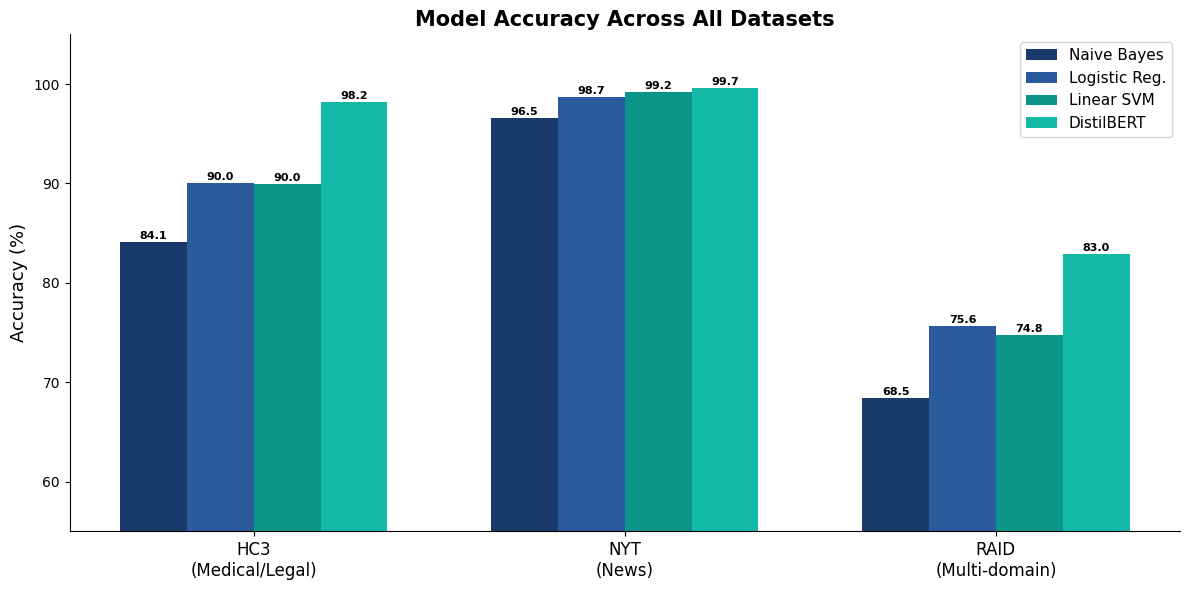

✅ Plot 1 saved


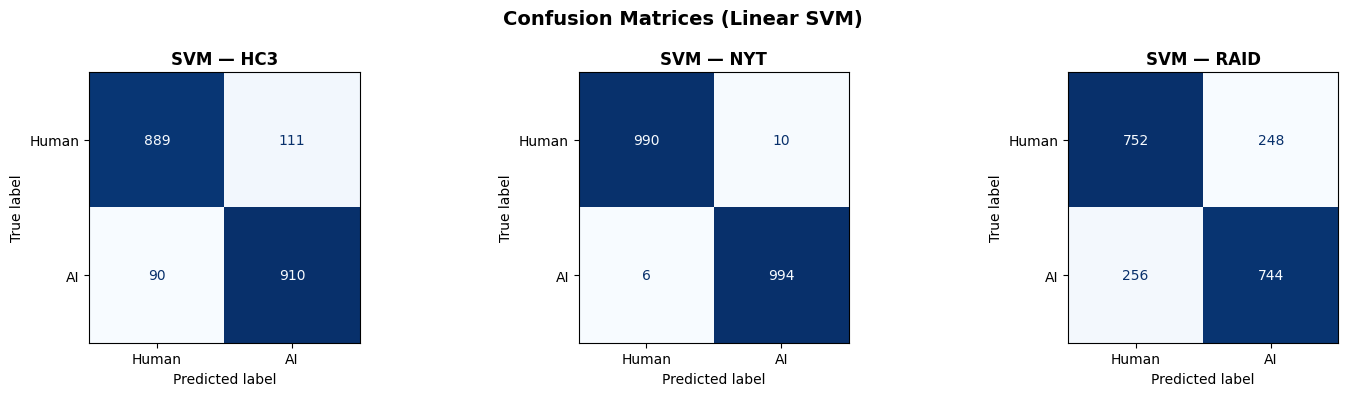

✅ Plot 2 saved


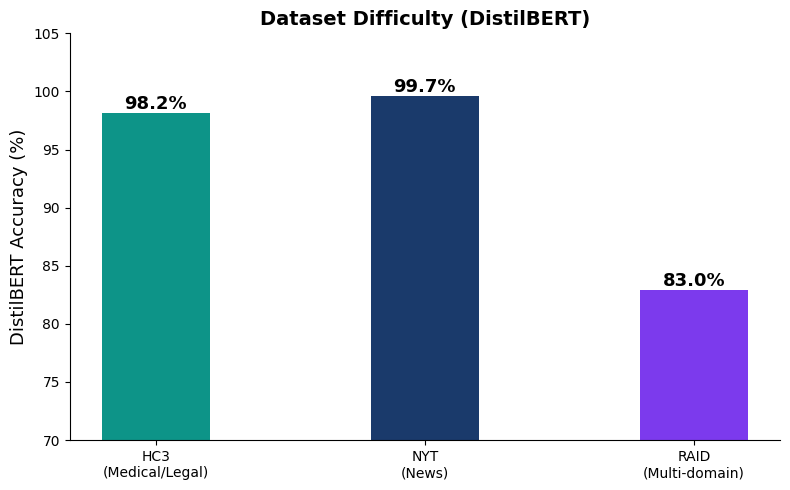

✅ Plot 3 saved

✅ All plots done!


In [10]:
# CELL 10 — Generate all plots
import matplotlib.pyplot as plt
import numpy as np

datasets = ["HC3\n(Medical/Legal)", "NYT\n(News)", "RAID\n(Multi-domain)"]
models   = ["Naive Bayes", "Logistic Reg.", "Linear SVM", "DistilBERT"]

scores = {
    "Naive Bayes":      [results_hc3["Naive Bayes"],  results_nyt["Naive Bayes"],  results_raid["Naive Bayes"]],
    "Logistic Reg.":    [results_hc3["Logistic Regression"], results_nyt["Logistic Regression"], results_raid["Logistic Regression"]],
    "Linear SVM":       [results_hc3["Linear SVM"],   results_nyt["Linear SVM"],   results_raid["Linear SVM"]],
    "DistilBERT":       [bert_hc3,                    bert_nyt,                    bert_raid],
}

# Plot 1 — Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x   = np.arange(len(datasets))
w   = 0.18
colors = ["#1A3A6B","#2A5A9B","#0D9488","#14B8A6"]
for idx, (model, vals) in enumerate(scores.items()):
    bars = ax.bar(x + idx*w, [v*100 for v in vals], w,
                  label=model, color=colors[idx])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"{bar.get_height():.1f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x + w*1.5)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylim(55, 105)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title("Model Accuracy Across All Datasets", fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Plot 1 saved")

# Plot 2 — Confusion matrix RAID BERT (most interesting)
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rerun predictions for confusion matrices
for ax, (X_tr, X_te, y_tr, y_te, name) in zip(axes, [
    (X_tr_hc3,  X_te_hc3,  y_tr_hc3,  y_te_hc3,  "HC3"),
    (X_tr_nyt,  X_te_nyt,  y_tr_nyt,  y_te_nyt,  "NYT"),
    (X_tr_raid, X_te_raid, y_tr_raid, y_te_raid, "RAID"),
]):
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    svm   = LinearSVC(max_iter=2000)
    svm.fit(tfidf.fit_transform(X_tr), y_tr)
    preds = svm.predict(tfidf.transform(X_te))
    cm    = confusion_matrix(y_te, preds)
    disp  = ConfusionMatrixDisplay(cm, display_labels=["Human","AI"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"SVM — {name}", fontsize=12, fontweight="bold")

plt.suptitle("Confusion Matrices (Linear SVM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("✅ Plot 2 saved")

# Plot 3 — Difficulty comparison
fig, ax = plt.subplots(figsize=(8, 5))
bert_scores = [bert_hc3*100, bert_nyt*100, bert_raid*100]
colors_d    = [C if C else "#0D9488" for C in ["#0D9488","#1A3A6B","#7C3AED"]]
bars = ax.bar(datasets, bert_scores, color=["#0D9488","#1A3A6B","#7C3AED"], width=0.4)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{bar.get_height():.1f}%", ha="center", fontsize=13, fontweight="bold")
ax.set_ylim(70, 105)
ax.set_ylabel("DistilBERT Accuracy (%)", fontsize=13)
ax.set_title("Dataset Difficulty (DistilBERT)", fontsize=14, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dataset_difficulty.png", dpi=150)
plt.show()
print("✅ Plot 3 saved")

print("\n✅ All plots done!")

In [11]:
# Quick check — make sure all results are still in memory
print("HC3 results:",  results_hc3)
print("NYT results:",  results_nyt)
print("RAID results:", results_raid)
print("BERT HC3:",     bert_hc3)
print("BERT NYT:",     bert_nyt)
print("BERT RAID:",    bert_raid)

HC3 results: {'Naive Bayes': 0.841, 'Logistic Regression': 0.9, 'Linear SVM': 0.8995}
NYT results: {'Naive Bayes': 0.9655, 'Logistic Regression': 0.9865, 'Linear SVM': 0.992}
RAID results: {'Naive Bayes': 0.6845, 'Logistic Regression': 0.7565, 'Linear SVM': 0.748}
BERT HC3: 0.9815
BERT NYT: 0.9965
BERT RAID: 0.8295


In [12]:
# CELL 11 — Input/Output Examples (for slides)
print("="*55)
print("INPUT / OUTPUT EXAMPLES")
print("="*55)

# Re-run SVM for predictions
tfidf_ex = TfidfVectorizer(stop_words="english", max_features=5000)
svm_ex   = LinearSVC(max_iter=2000)
svm_ex.fit(tfidf_ex.fit_transform(X_tr_hc3), y_tr_hc3)
preds_hc3 = svm_ex.predict(tfidf_ex.transform(X_te_hc3))

label_map = {0: "HUMAN", 1: "AI"}

for dataset, X_te, y_te, preds, name in [
    (None, X_te_hc3, y_te_hc3, preds_hc3, "HC3 (Medical/Legal)"),
]:
    print(f"\n--- {name} ---")
    X_list = list(X_te)
    y_list = list(y_te)
    p_list = list(preds)

    correct   = [(X_list[i], y_list[i], p_list[i]) for i in range(len(y_list)) if y_list[i]==p_list[i]]
    incorrect = [(X_list[i], y_list[i], p_list[i]) for i in range(len(y_list)) if y_list[i]!=p_list[i]]

    print("\n✅ CORRECT PREDICTIONS:")
    for txt, true, pred in correct[:3]:
        print(f"\nInput:  {txt[:200]}...")
        print(f"True:      {label_map[true]}")
        print(f"Predicted: {label_map[pred]} ✓")

    print("\n❌ INCORRECT PREDICTIONS (misclassified):")
    for txt, true, pred in incorrect[:2]:
        print(f"\nInput:  {txt[:200]}...")
        print(f"True:      {label_map[true]}")
        print(f"Predicted: {label_map[pred]} ✗")

INPUT / OUTPUT EXAMPLES

--- HC3 (Medical/Legal) ---

✅ CORRECT PREDICTIONS:

Input:  Because they know parents watch with their children , and as long as they do n't cross the line ( nudity ) noones going to stop them cause " it 's just fun and games " I 'm not saying for a second tha...
True:      HUMAN
Predicted: HUMAN ✓

Input:  Mexico gained independence from Spain in 1821. The process of independence began in 1810 with the start of the Mexican War of Independence and ended on September 27, 1821, when the Treaty of C√≥rdoba ...
True:      AI
Predicted: AI ✓

Input:  Their " employer " is the taxpayer , and the taxpayer is not directly concerned with the outcome of their taxes ....
True:      HUMAN
Predicted: HUMAN ✓

❌ INCORRECT PREDICTIONS (misclassified):

Input:  "Finna" and "gon na" are both informal ways of saying "going to" in spoken English. They are often used in casual conversation, and are not considered standard English.

"Gon na" is short for "going...
True:      AI
Pr

In [14]:
# CELL 14 — GPT-3.5 Zero-Shot Prompting
from openai import OpenAI
import time

client = OpenAI(api_key="GPT3.5 API KEY")

PROMPT = """You are an expert at detecting AI-generated text.

Read the following text and classify it as either HUMAN or AI.

- HUMAN: written by a real person
- AI: generated by an AI like ChatGPT

Text:
\"\"\"
{text}
\"\"\"

Respond with exactly one word: HUMAN or AI"""

def classify_gpt(text, max_chars=500):
    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role":"user","content":PROMPT.format(text=text[:max_chars])}],
            max_tokens=5,
            temperature=0,
        )
        answer = response.choices[0].message.content.strip().upper()
        if "HUMAN" in answer: return 0
        elif "AI" in answer:   return 1
        else:                  return -1
    except Exception as e:
        print(f"Error: {e}")
        return -1

def eval_gpt(X_test, y_test, name, n=200):
    print(f"\n{'='*50}")
    print(f"GPT-3.5 ZERO-SHOT — {name} (n={n})")
    print(f"{'='*50}")
    X_s = list(X_test)[:n]
    y_s = list(y_test)[:n]
    preds = []
    for i, text in enumerate(X_s):
        preds.append(classify_gpt(text))
        if (i+1) % 50 == 0:
            print(f"  {i+1}/{n} done...")
        time.sleep(0.5)
    valid = [(p,t) for p,t in zip(preds,y_s) if p!=-1]
    p_clean = [v[0] for v in valid]
    t_clean = [v[1] for v in valid]
    acc = accuracy_score(t_clean, p_clean)
    print(f"\nAccuracy: {acc:.4f}")
    print(classification_report(t_clean, p_clean, target_names=["Human","AI"]))
    return acc

gpt_hc3  = eval_gpt(X_te_hc3,  y_te_hc3,  "HC3")
gpt_nyt  = eval_gpt(X_te_nyt,  y_te_nyt,  "NYT")
gpt_raid = eval_gpt(X_te_raid, y_te_raid, "RAID")

print(f"\n✅ GPT done!")
print(f"HC3:  {gpt_hc3:.4f}")
print(f"NYT:  {gpt_nyt:.4f}")
print(f"RAID: {gpt_raid:.4f}")


GPT-3.5 ZERO-SHOT — HC3 (n=200)
  50/200 done...
  100/200 done...
  150/200 done...
  200/200 done...

Accuracy: 0.3350
              precision    recall  f1-score   support

       Human       0.37      0.41      0.39       103
          AI       0.29      0.26      0.27        97

    accuracy                           0.34       200
   macro avg       0.33      0.33      0.33       200
weighted avg       0.33      0.34      0.33       200


GPT-3.5 ZERO-SHOT — NYT (n=200)
  50/200 done...
  100/200 done...
  150/200 done...
  200/200 done...

Accuracy: 0.4550
              precision    recall  f1-score   support

       Human       0.48      0.74      0.58       103
          AI       0.36      0.15      0.22        97

    accuracy                           0.46       200
   macro avg       0.42      0.45      0.40       200
weighted avg       0.42      0.46      0.40       200


GPT-3.5 ZERO-SHOT — RAID (n=200)
  50/200 done...
  100/200 done...
  150/200 done...
  200/200 done.

In [15]:
# CELL 15 — Final Results Summary
print("="*65)
print(f"{'Model':<25} {'HC3':>10} {'NYT':>10} {'RAID':>10}")
print("="*65)
print(f"{'Naive Bayes':<25} {results_hc3['Naive Bayes']*100:>9.1f}% {results_nyt['Naive Bayes']*100:>9.1f}% {results_raid['Naive Bayes']*100:>9.1f}%")
print(f"{'Logistic Regression':<25} {results_hc3['Logistic Regression']*100:>9.1f}% {results_nyt['Logistic Regression']*100:>9.1f}% {results_raid['Logistic Regression']*100:>9.1f}%")
print(f"{'Linear SVM':<25} {results_hc3['Linear SVM']*100:>9.1f}% {results_nyt['Linear SVM']*100:>9.1f}% {results_raid['Linear SVM']*100:>9.1f}%")
print(f"{'DistilBERT':<25} {bert_hc3*100:>9.1f}% {bert_nyt*100:>9.1f}% {bert_raid*100:>9.1f}%")
print(f"{'GPT-3.5 Zero-Shot':<25} {gpt_hc3*100:>9.1f}% {gpt_nyt*100:>9.1f}% {gpt_raid*100:>9.1f}%")
print("="*65)

Model                            HC3        NYT       RAID
Naive Bayes                    84.1%      96.5%      68.5%
Logistic Regression            90.0%      98.7%      75.6%
Linear SVM                     90.0%      99.2%      74.8%
DistilBERT                     98.2%      99.7%      83.0%
GPT-3.5 Zero-Shot              33.5%      45.5%      50.3%


In [16]:
# CELL 16 — Download everything
from google.colab import files
files.download("accuracy_comparison.png")
files.download("confusion_matrices.png")
files.download("dataset_difficulty.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

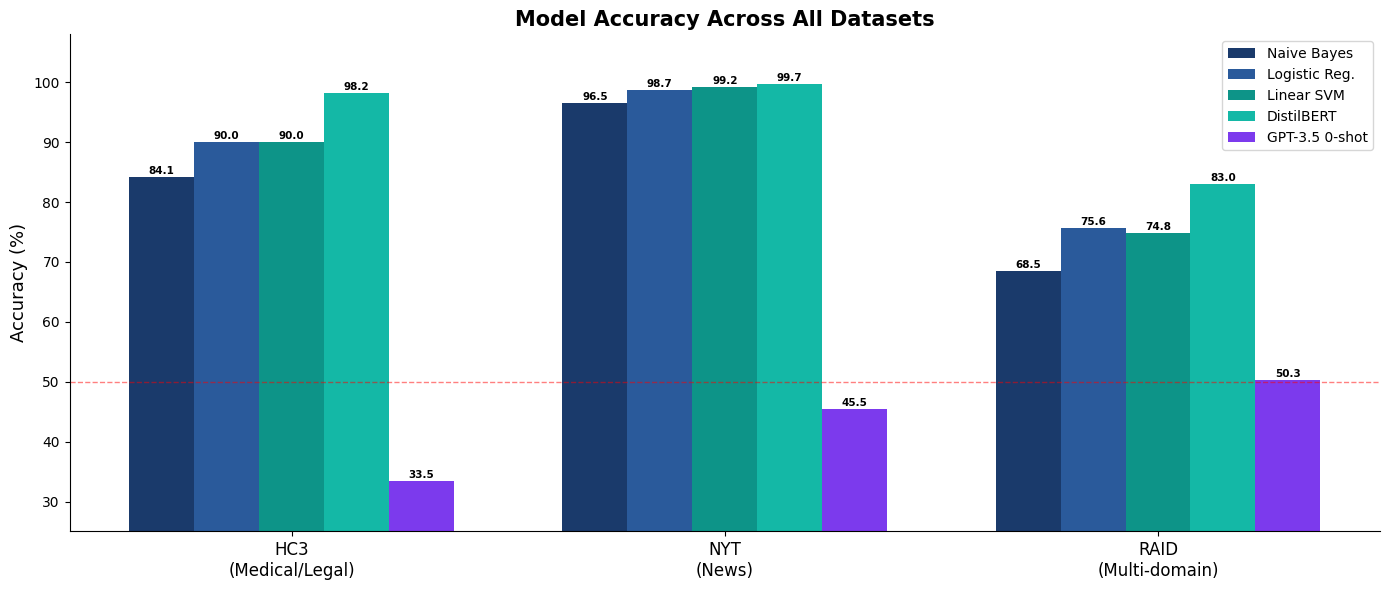

✅ Plot 1 saved


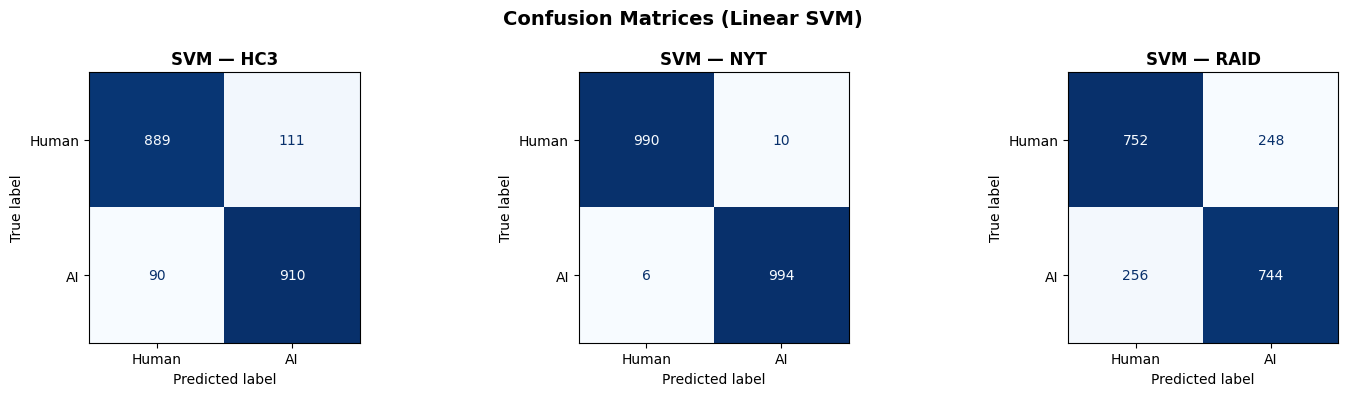

✅ Plot 2 saved


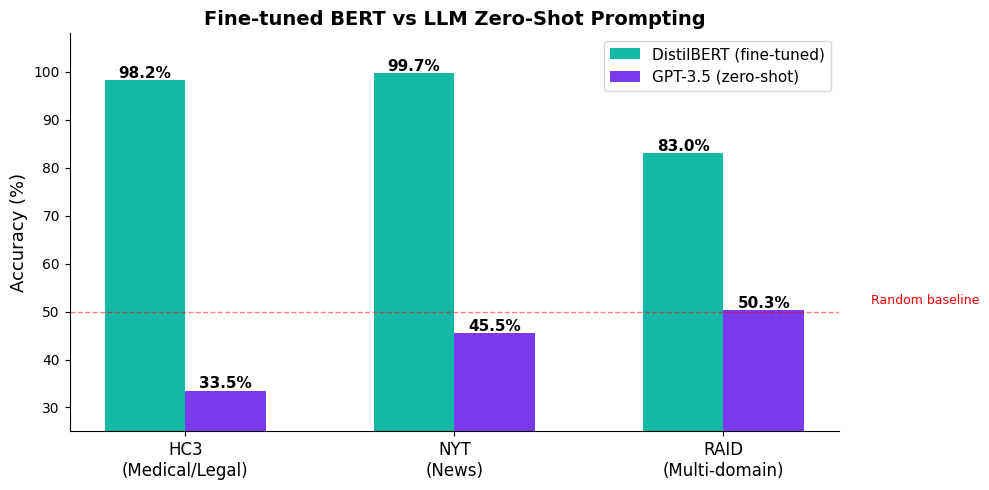

✅ Plot 3 saved


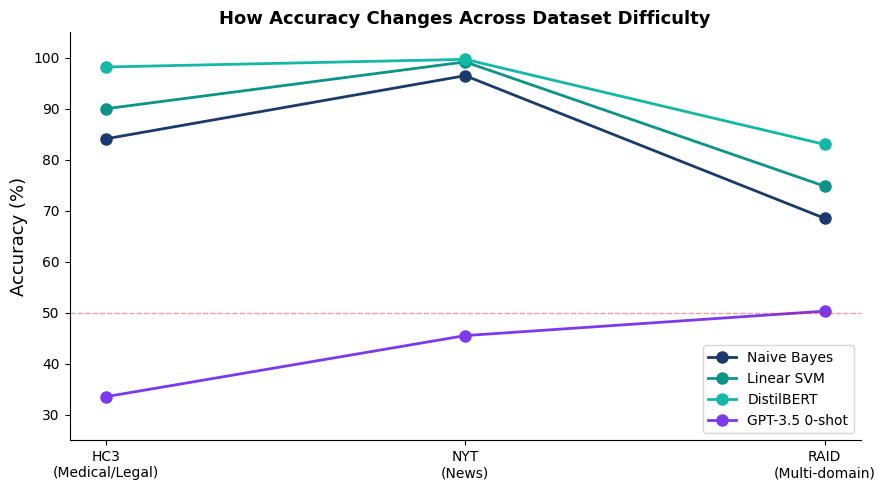

✅ Plot 4 saved

✅ All 4 plots done!


In [17]:
# CELL 16 — Regenerate all plots with GPT-3.5 included
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

datasets = ["HC3\n(Medical/Legal)", "NYT\n(News)", "RAID\n(Multi-domain)"]
models   = ["Naive Bayes", "Logistic Reg.", "Linear SVM", "DistilBERT", "GPT-3.5 0-shot"]
colors   = ["#1A3A6B", "#2A5A9B", "#0D9488", "#14B8A6", "#7C3AED"]

scores = {
    "Naive Bayes":     [84.1, 96.5, 68.5],
    "Logistic Reg.":   [90.0, 98.7, 75.6],
    "Linear SVM":      [90.0, 99.2, 74.8],
    "DistilBERT":      [98.2, 99.7, 83.0],
    "GPT-3.5 0-shot":  [33.5, 45.5, 50.3],
}

# PLOT 1 — Grouped bar chart all models
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(datasets))
w = 0.15
for idx, (model, vals) in enumerate(scores.items()):
    bars = ax.bar(x + idx*w, vals, w, label=model, color=colors[idx])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{bar.get_height():.1f}", ha="center", fontsize=7.5, fontweight="bold")
ax.set_xticks(x + w*2)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylim(25, 108)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title("Model Accuracy Across All Datasets", fontsize=15, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.axhline(y=50, color="red", linestyle="--", linewidth=1, alpha=0.5, label="Random baseline")
plt.tight_layout()
plt.savefig("accuracy_all_models.png", dpi=150)
plt.show()
print("✅ Plot 1 saved")

# PLOT 2 — Confusion matrices SVM
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (X_tr, X_te, y_tr, y_te, name) in zip(axes, [
    (X_tr_hc3,  X_te_hc3,  y_tr_hc3,  y_te_hc3,  "HC3"),
    (X_tr_nyt,  X_te_nyt,  y_tr_nyt,  y_te_nyt,  "NYT"),
    (X_tr_raid, X_te_raid, y_tr_raid, y_te_raid, "RAID"),
]):
    tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
    svm   = LinearSVC(max_iter=2000)
    svm.fit(tfidf.fit_transform(X_tr), y_tr)
    preds = svm.predict(tfidf.transform(X_te))
    cm    = confusion_matrix(y_te, preds)
    disp  = ConfusionMatrixDisplay(cm, display_labels=["Human","AI"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"SVM — {name}", fontsize=12, fontweight="bold")
plt.suptitle("Confusion Matrices (Linear SVM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("✅ Plot 2 saved")

# PLOT 3 — BERT vs GPT comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(datasets))
w = 0.3
b1 = ax.bar(x - w/2, [98.2, 99.7, 83.0], w, label="DistilBERT (fine-tuned)", color="#14B8A6")
b2 = ax.bar(x + w/2, [33.5, 45.5, 50.3], w, label="GPT-3.5 (zero-shot)",     color="#7C3AED")
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylim(25, 108)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title("Fine-tuned BERT vs LLM Zero-Shot Prompting", fontsize=14, fontweight="bold")
ax.axhline(y=50, color="red", linestyle="--", linewidth=1, alpha=0.5)
ax.text(2.55, 51.5, "Random baseline", fontsize=9, color="red")
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("bert_vs_gpt.png", dpi=150)
plt.show()
print("✅ Plot 3 saved")

# PLOT 4 — Dataset difficulty
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(datasets))
w = 0.2
for idx, (model, vals, color) in enumerate([
    ("Naive Bayes",    [84.1, 96.5, 68.5], "#1A3A6B"),
    ("Linear SVM",     [90.0, 99.2, 74.8], "#0D9488"),
    ("DistilBERT",     [98.2, 99.7, 83.0], "#14B8A6"),
    ("GPT-3.5 0-shot", [33.5, 45.5, 50.3], "#7C3AED"),
]):
    ax.plot(datasets, vals, "o-", label=model, color=color, linewidth=2, markersize=8)
ax.set_ylim(25, 105)
ax.set_ylabel("Accuracy (%)", fontsize=13)
ax.set_title("How Accuracy Changes Across Dataset Difficulty", fontsize=13, fontweight="bold")
ax.axhline(y=50, color="red", linestyle="--", linewidth=1, alpha=0.4)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("dataset_difficulty.png", dpi=150)
plt.show()
print("✅ Plot 4 saved")

print("\n✅ All 4 plots done!")

In [18]:
# CELL 17 — Download all plots
from google.colab import files
files.download("accuracy_all_models.png")
files.download("confusion_matrices.png")
files.download("bert_vs_gpt.png")
files.download("dataset_difficulty.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# CELL 17 — Download all plots
from google.colab import files
files.download("accuracy_all_models.png")
files.download("confusion_matrices.png")
files.download("bert_vs_gpt.png")
files.download("dataset_difficulty.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>